# 1장 실습 — Sim2Real의 좌표계

시뮬레이터를 쓰는 이유는 단순하다. 빠르고, 싸고, 위험하지 않다. 로봇 팔 하나로 하루에 수백 판을 돌릴 수 있다면 시뮬레이터에서는 같은 시간에 수백만 판을 돌린다.

그런데 그 판들이 **무엇에 대한** 판인지가 문제다. 이 노트북은 세 가지를 잰다.

1. 시뮬이 실제로 얼마나 빠른가 — 이 이점이 이 책 전체의 전제다
2. 같은 모델이 같은 답을 내는가 — 적분기와 타임스텝을 바꾸면 어떻게 되는가
3. 네 가지 갭이 각각 얼마나 큰가 — 이 책의 지도

셋째가 이 노트북의 결론이다. 앞으로 열일곱 장에 걸쳐 메울 갭들을 여기서 한 번에 늘어놓고 크기를 잰다.

실행 시간은 CPU에서 2분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    # 화면에서 차지하는 칸 수. 한글은 한 글자가 두 칸이다
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    # f"{s:<12}" 는 글자 수로 세어 한글 표를 어긋나게 한다
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__)

mujoco 3.13.0


## 첫 장면

이 책이 끝까지 쓸 과제를 여기서 세운다. 원통형 밀대가 원반을 밀어 목표 원 안에 넣는다. 평면 밀기는 sim2real 연구에서 가장 오래 쓰인 과제 중 하나다. 단순해 보이지만 접촉과 마찰이 전부 들어 있어서, 시뮬과 실기가 갈리는 자리를 거의 다 담고 있다.

모델은 스무 줄이 안 된다. 바닥 평면 하나, 원반 하나, 밀대 하나. 밀대는 x·y 두 축으로만 움직이고 속도 명령을 받는다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="{dt}" integrator="{integrator}"
          iterations="{iters}"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction="{mu} .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom name="block" type="cylinder" size=".03 .03" mass=".25"
            friction="{mu} .005 .0001" rgba=".89 .17 .14 1"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom name="pusher" type="cylinder" size=".012 .03" mass="4"
            rgba=".35 .35 .35 1"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="{kv}"/>
    <velocity joint="py" kv="{kv}"/>
  </actuator>
</mujoco>
'''

CTRL_HZ = 20       # 정책이 명령을 내는 주기
EP_STEPS = 140     # 한 판의 제어 스텝 수 (7초)
GOAL_R = .04       # 이 반경 안에 들어오면 성공
STANDOFF = .045    # 원반 뒤 접점까지의 거리
STOP = .015        # 이만큼 가까우면 손을 뗀다


def make(mu=.6, kv=120., dt=.004,
         integrator="implicitfast", iters=100):
    xml = XML.format(mu=mu, kv=kv, dt=dt, integrator=integrator,
                     iters=iters)
    m = mujoco.MjModel.from_xml_string(xml)
    return m, mujoco.MjData(m)


def unit(v):
    n = np.linalg.norm(v)
    return v / n if n > 1e-9 else np.zeros_like(v)


def reset(m, d, rng):
    mujoco.mj_resetData(m, d)
    bx, by = rng.uniform(-.03, .03, 2)
    d.qpos[0:2] = [bx, by]
    d.qpos[2] = .031
    d.qpos[7:9] = [bx - .09, by]     # 밀대는 원반 뒤에서 시작한다
    mujoco.mj_forward(m, d)
    return np.array([.28, 0.]) + rng.uniform(-.04, .04, 2)


def push_policy(b, p, g, speed=.25):
    # 원반 뒤로 돌아가 목표 방향으로 민다
    if np.linalg.norm(g - b) < STOP:
        return np.zeros(2)
    c = b - unit(g - b) * STANDOFF
    if np.linalg.norm(p - c) > .012:
        return unit(c - p) * max(speed, .3)
    return unit(g - b) * speed


def episode(m, d, rng, obs_noise=0., lat=0, keep=False):
    # 한 판. keep 이면 원반 궤적을 함께 돌려준다
    goal = reset(m, d, rng)
    sub = int(round(1 / CTRL_HZ / m.opt.timestep))
    buf = [np.zeros(2)] * (lat + 1)
    path = []
    for _ in range(EP_STEPS):
        b = d.qpos[0:2]
        if obs_noise:
            b = b + rng.normal(0, obs_noise, 2)
        u = push_policy(np.asarray(b),
                        np.asarray(d.qpos[7:9]), goal)
        buf.append(u)
        d.ctrl[:] = buf[-1 - lat]
        for _ in range(sub):
            mujoco.mj_step(m, d)
        if keep:
            path.append(d.qpos[0:2].copy())
    end = d.qpos[0:2].copy()
    return (end, goal, np.array(path)) if keep else (end, goal)

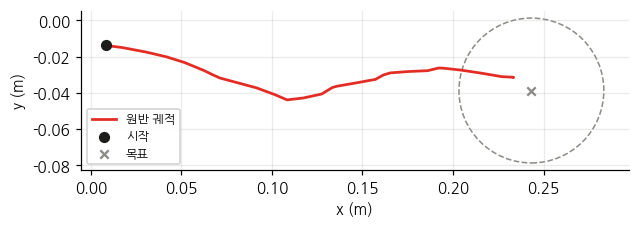

최종 거리 0.0122 m (목표 반경 0.04 m)


In [4]:
m, d = make()
end, goal, path = episode(m, d, np.random.default_rng(0), keep=True)

fig, ax = plt.subplots(figsize=(6.0, 3.2))
ax.plot(path[:, 0], path[:, 1], "-", color=RED, lw=1.8,
        label="원반 궤적")
ax.scatter(*path[0], s=40, color=INK, zorder=3, label="시작")
circle = plt.Circle(goal, GOAL_R, fill=False, ls="--", color=GREY)
ax.add_patch(circle)
ax.scatter(*goal, s=30, marker="x", color=GREY, zorder=3,
           label="목표")
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.legend(fontsize=8, loc="lower left", framealpha=.9)
plt.tight_layout()
plt.show()

print(f"최종 거리 {np.linalg.norm(end - goal):.4f} m "
      f"(목표 반경 {GOAL_R} m)")

## 시뮬은 얼마나 빠른가

이 책의 전제를 먼저 숫자로 확인한다. 이 모델을 CPU 한 코어에서 굴리면 실시간의 몇 배가 나오는가.

In [5]:
m, d = make()
mujoco.mj_resetData(m, d)
d.ctrl[:] = [.2, .05]

for _ in range(200):          # 워밍업
    mujoco.mj_step(m, d)

n = 20_000
t0 = time.perf_counter()
for _ in range(n):
    mujoco.mj_step(m, d)
el = time.perf_counter() - t0

sps = n / el
sim_sec = n * m.opt.timestep
print(f"물리 스텝      {sps:>12,.0f} 스텝/초")
print(f"시뮬 시간      {sim_sec:>12.1f} 초를 {el:.2f}초에")
print(f"실시간 대비    {sim_sec / el:>12.1f} 배")
print()
ep_sec = EP_STEPS / CTRL_HZ
ep_cost = EP_STEPS * int(round(1 / CTRL_HZ / m.opt.timestep)) / sps
print(f"한 판({ep_sec:.0f}초짜리)에 {ep_cost*1000:.0f} ms")
print(f"→ 한 코어로 한 시간이면 {3600/ep_cost:,.0f} 판")

물리 스텝           157,455 스텝/초
시뮬 시간              80.0 초를 0.13초에
실시간 대비           629.8 배

한 판(7초짜리)에 11 ms
→ 한 코어로 한 시간이면 337,403 판


## 같은 모델이 같은 답을 내는가

먼저 가장 기초적인 것부터 확인한다. 같은 모델, 같은 초기 조건, 같은 명령이면 같은 결과가 나오는가. 재현되지 않는 시뮬레이터로는 아무것도 잴 수 없다.

In [6]:
m, d = make()
a = episode(m, d, np.random.default_rng(7))[0]
b = episode(m, d, np.random.default_rng(7))[0]
print(f"두 번 굴린 결과의 차이: {np.abs(a - b).max():.3e} m")
print("비트 단위로 같은가:", np.array_equal(a, b))

두 번 굴린 결과의 차이: 0.000e+00 m
비트 단위로 같은가: True


## 적분기와 타임스텝을 바꾸면

이제 중요한 실험이다. **물리 모델은 한 글자도 안 바꾸고** 수치 적분 방법만 바꾼다. 마찰도 질량도 형상도 그대로다. 그래도 답이 달라지는가.

여기서는 밀기 과제 대신 **참값을 아는 문제**를 쓴다. 원반에 초기 속도를 주고 마찰로 멈출 때까지 미끄러진 거리를 잰다. 고등학교 물리다.

> 거리 = 초기속도² / (2 · 마찰계수 · 중력가속도)

참값이 있으면 「기준과 얼마나 다른가」가 아니라 **「정답에서 얼마나 벗어났는가」**를 물을 수 있다. 밀기 과제로 같은 실험을 하면 숫자가 타임스텝과 무관하게 널뛴다. 접촉과 피드백이 섞이면 작은 차이가 증폭돼 수렴 자체가 안 보이기 때문이다. 재려는 것을 격리한다는 원칙이 여기에도 적용된다.

In [7]:
def slide(dt, integrator, v0=1.2, mu=.6, iters=100):
    # 초기 속도를 준 원반이 마찰로 멈출 때까지 간 거리
    m, d = make(mu=mu, dt=dt, integrator=integrator, iters=iters)
    mujoco.mj_resetData(m, d)
    d.qpos[2] = .031
    d.qpos[7] = -.6          # 밀대는 멀리 치운다
    d.qvel[0] = v0
    mujoco.mj_forward(m, d)
    for _ in range(int(8. / dt)):
        mujoco.mj_step(m, d)
        if abs(d.qvel[0]) < 1e-4:
            break
    return d.qpos[0]


V0, MU = 1.2, .6
theory = V0 ** 2 / (2 * MU * 9.81)
print(f"이론값  d = v0^2 / (2 mu g) = {theory*100:.2f} cm")

dts = [.0005, .001, .002, .004, .008, .016]
ints = ["Euler", "implicitfast", "implicit", "RK4"]
err, cost = {}, {}
for it in ints:
    e, c = [], []
    for dt in dts:
        t0 = time.perf_counter()
        x = slide(dt, it)
        c.append(time.perf_counter() - t0)
        e.append(x - theory)
    err[it], cost[it] = e, c

print()
print(pad("적분기", 15) + "".join(pad(f"dt={v*1000:g}ms", 11, True)
                                  for v in dts))
for it in ints:
    row = "".join(pad(f"{v*1000:+.2f}", 11, True) for v in err[it])
    print(pad(it, 15) + row)
print()
print("단위는 mm. 이론값에서 벗어난 거리")

이론값  d = v0^2 / (2 mu g) = 12.23 cm



적분기            dt=0.5ms     dt=1ms     dt=2ms     dt=4ms     dt=8ms    dt=16ms
Euler                +1.05      +0.70      -0.33      -1.55      -4.11      -7.78
implicitfast         +1.05      +0.70      -0.33      -1.55      -4.11      -7.78
implicit             +1.05      +0.70      -0.33      -1.55      -4.11      -7.78
RK4                  +1.25      +1.54      +1.05      +1.75      +1.60      +1.45

단위는 mm. 이론값에서 벗어난 거리


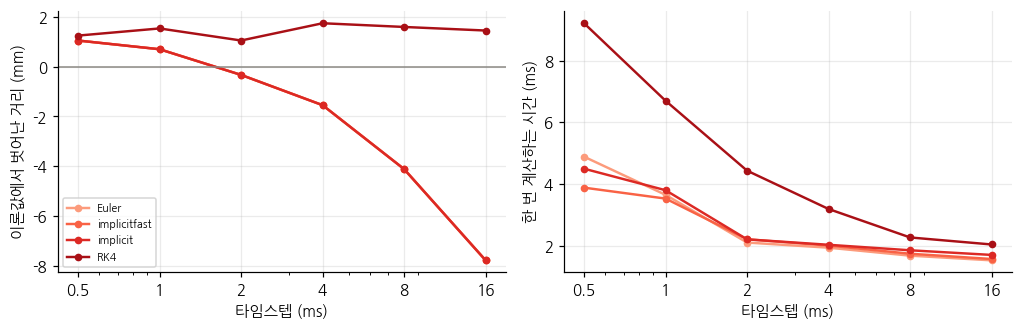

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.4, 3.1))
ms = np.array(dts) * 1000
for k, it in enumerate(ints):
    col = plt.cm.Reds(.35 + .17 * k)
    a1.plot(ms, np.array(err[it]) * 1000, "o-", color=col,
            lw=1.6, ms=4, label=it)
    a2.plot(ms, np.array(cost[it]) * 1000, "o-", color=col,
            lw=1.6, ms=4, label=it)
a1.axhline(0, color=GREY, lw=1)
a1.set_xlabel("타임스텝 (ms)")
a1.set_ylabel("이론값에서 벗어난 거리 (mm)")
a2.set_xlabel("타임스텝 (ms)")
a2.set_ylabel("한 번 계산하는 시간 (ms)")
for a in (a1, a2):
    a.set_xscale("log")
    a.set_xticks(ms)
    a.set_xticklabels([f"{v:g}" for v in ms])
    a.xaxis.set_minor_formatter(plt.NullFormatter())
a1.legend(fontsize=7, loc="lower left")
plt.tight_layout()
plt.show()

## 네 갭의 크기

마지막이 이 노트북의 결론이다. 1장 본문에서 갭을 넷으로 나눴다. 각각이 실제로 얼마나 큰지를 여기서 잰다.

기준은 「아무 갭도 없는」 시뮬이다. 거기서 갭을 하나씩만 켜고 50판의 평균 최종 거리가 얼마나 달라지는지 본다. 성공률도 함께 보는데, 이 과제에서는 성공률이 거의 움직이지 않아 평균 거리 쪽이 훨씬 민감한 자다.

| 갭 | 이 실험에서 켜는 것 |
|---|---|
| 동역학 | 마찰계수를 0.6에서 0.35로 |
| 인식 | 원반 위치 관측에 4mm 잡음 |
| 구동 | 액추에이터 게인을 120에서 300으로 |
| 시스템 설계 | 제어 지연 2스텝(100ms) |

In [9]:
BASE = dict(mu=.60, kv=120.)
GAPS = {
    "갭 없음":        (BASE, dict()),
    "동역학 (마찰)":   (dict(mu=.35, kv=120.), dict()),
    "인식 (관측 잡음)": (BASE, dict(obs_noise=.004)),
    "구동 (게인)":     (dict(mu=.60, kv=300.), dict()),
    "시스템 (지연)":   (BASE, dict(lat=2)),
}

NEP = 50
res = {}
for name, (mk_kw, ep_kw) in GAPS.items():
    mm, dd = make(**mk_kw)
    dists = []
    for i in range(NEP):
        e, g = episode(mm, dd, np.random.default_rng(i), **ep_kw)
        dists.append(np.linalg.norm(e - g))
    res[name] = np.array(dists)

base = res["갭 없음"]
print(pad("갭", 20) + pad("평균 거리", 12, True)
      + pad("성공률", 10, True) + pad("기준 대비", 12, True))
for name, v in res.items():
    ratio = v.mean() / base.mean()
    print(pad(name, 20) + pad(f"{v.mean()*1000:.1f} mm", 12, True)
          + pad(f"{(v < GOAL_R).mean():.2f}", 10, True)
          + pad(f"{ratio:.2f}배", 12, True))

갭                     평균 거리    성공률   기준 대비
갭 없음                   6.2 mm      1.00      1.00배
동역학 (마찰)             7.2 mm      1.00      1.16배
인식 (관측 잡음)         59.5 mm      0.88      9.58배
구동 (게인)               5.8 mm      1.00      0.93배
시스템 (지연)            20.6 mm      0.98      3.31배


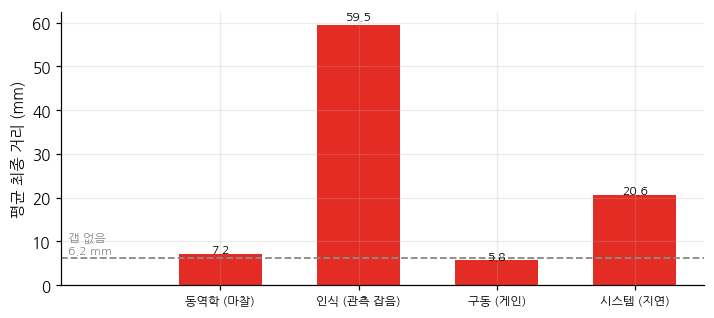

In [10]:
names = [k for k in res if k != "갭 없음"]
vals = [res[k].mean() * 1000 for k in names]
b0 = base.mean() * 1000

fig, ax = plt.subplots(figsize=(6.6, 3.0))
ax.bar(np.arange(len(names)), vals, color=RED, width=.6)
ax.axhline(b0, ls="--", color=GREY, lw=1.2)
ax.set_xlim(-1.15, len(names) - .5)
ax.text(-1.1, b0 * 1.15, f"갭 없음\n{b0:.1f} mm",
        fontsize=8, color=GREY, ha="left")
ax.set_xticks(np.arange(len(names)))
ax.set_xticklabels(names, fontsize=8)
ax.set_ylabel("평균 최종 거리 (mm)")
for i, v in enumerate(vals):
    ax.text(i, v * 1.02, f"{v:.1f}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 정리

**시뮬레이터의 이점은 실측으로 확인된다.** CPU 한 코어에서 실시간의 수백 배가 나오고, 한 시간이면 수만 판을 돌린다. 이 책이 존재하는 이유이자, 이 책이 다루는 모든 위험의 출처다.

**물리 모델이 같아도 답은 하나가 아니다.** 적분기와 타임스텝만 바꿔도 최종 위치가 목표 반경에 맞먹는 크기로 움직인다. 시뮬 결과를 인용할 때 모델 파일만으로는 부족하고, 적분 설정까지 함께 적어야 하는 이유다.

**정확도는 계산 시간으로 산다.** 타임스텝을 줄이면 정확해지지만 판 수가 줄어든다. sim2real의 첫 번째 교환은 시뮬과 실기 사이가 아니라 시뮬 안에 있다.

**네 갭의 크기는 같지 않고, 어떤 갭은 시뮬을 오히려 쉽게 만든다.** 액추에이터 게인을 올린 시뮬은 갭이 없는 시뮬보다 평균 거리가 짧다. 갭이 반드시 성적을 떨어뜨리는 것은 아니다. 그리고 **시뮬을 쉽게 만드는 방향의 갭이 가장 위험하다.** 시뮬에서 잘 되는 정책을 골라 실기에 올리면 무너지는데, 시뮬만 보고 있으면 그 사실을 알 방법이 없기 때문이다.

**성공률은 이 차이를 거의 못 잡는다.** 다섯 설정 중 넷이 성공률 1.00 또는 0.98인데 평균 거리는 열 배 가까이 벌어진다. 2권 14장에서 성공률 하나로는 모른다고 한 이야기가 시뮬 쪽에서도 그대로다.

3장에서는 이 갭들을 **순위 예측력**이라는 더 쓸모 있는 자로 다시 잰다. 그리고 그때 순서가 바뀐다.